In [17]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define path
mypath = "/content/drive/MyDrive/AAX/Seminar5"

# Unzip dataset
!cd $mypath && unzip -o dataset_Seminar5.zip

# Check files
!ls "$mypath"
!ls "$mypath/client_datasets"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  dataset_Seminar5.zip
  inflating: __MACOSX/._client_datasets  
  inflating: client_datasets/client_9_features.csv  
  inflating: __MACOSX/client_datasets/._client_9_features.csv  
  inflating: client_datasets/client_1_labels.csv  
  inflating: __MACOSX/client_datasets/._client_1_labels.csv  
  inflating: client_datasets/client_9_labels.csv  
  inflating: __MACOSX/client_datasets/._client_9_labels.csv  
  inflating: client_datasets/client_8_features.csv  
  inflating: __MACOSX/client_datasets/._client_8_features.csv  
  inflating: client_datasets/client_10_features.csv  
  inflating: __MACOSX/client_datasets/._client_10_features.csv  
  inflating: client_datasets/client_4_labels.csv  
  inflating: __MACOSX/client_datasets/._client_4_labels.csv  
  inflating: client_datasets/client_3_labels.csv  
  inflating: __MACOSX/client_datasets/._client_3_labels

# 1. Dataset Loading and Exploratory Analysis

In this last seminar, we work with a federated learning dataset, composed of Wi-Fi CSI measurements which are from different users. Each of them contains local data associated with different human poses. Here, unlike Seminar 2, the dataset is not from one client. Before defining the federated learning strategy, we will first explore the dataset distributions and analyze how data is distributed among clients.

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to client datasets
clients_path = mypath + "/client_datasets"

# Store client data
client_data = {}
client_sizes = {}

# Load all clients
for i in range(1, 11):

    features_file = os.path.join(clients_path, f"client_{i}_features.csv")
    labels_file = os.path.join(clients_path, f"client_{i}_labels.csv")

    X_client = pd.read_csv(features_file, header=None)
    y_client = pd.read_csv(labels_file, header=None)

    client_data[i] = (X_client, y_client)
    client_sizes[i] = len(X_client)

# Show number of samples per client
for client_id, size in client_sizes.items():
    print(f"Client {client_id}: {size} samples")

Client 1: 314 samples
Client 2: 113 samples
Client 3: 365 samples
Client 4: 207 samples
Client 5: 209 samples
Client 6: 202 samples
Client 7: 448 samples
Client 8: 142 samples
Client 9: 412 samples
Client 10: 64 samples


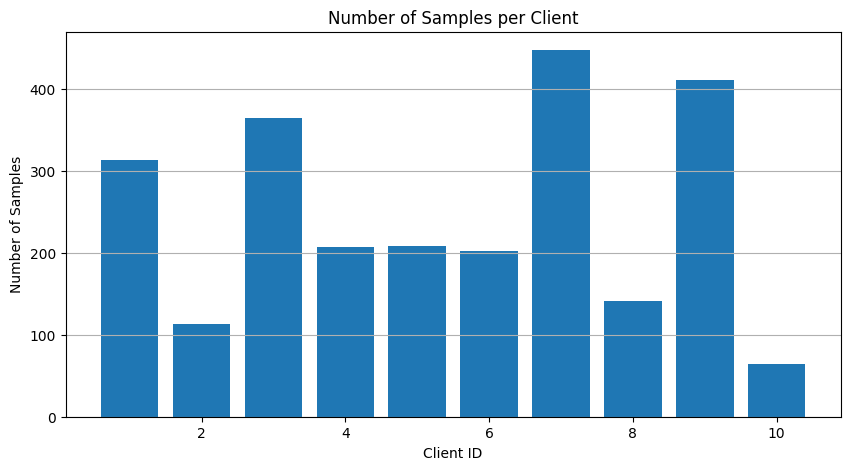

In [3]:
plt.figure(figsize=(10,5))

plt.bar(client_sizes.keys(), client_sizes.values())

plt.xlabel("Client ID")
plt.ylabel("Number of Samples")
plt.title("Number of Samples per Client")

plt.grid(axis='y')

plt.show()

The number of samples is not equally distributed among clients. Some clients, such as Client 7 and Client 9, contain significantly more samples than others like Client 10.

This could supose an issue in federated learning because the FedAvg aggregation mechanisms weights client contributions according to the amount of the local data. Therefore, clients with larger datasets will have more influence in the end of the global model.

This heterogeneous distribution also makes the learning problem more realistic, since in practical federated learning systems different devices usually contain different amounts of data.

**Class Distribution Across Clients**

In [4]:
# Analyze class distributions for each client

client_class_distribution = {}

for client_id, (X_client, y_client) in client_data.items():

    # Flatten labels into a 1D array, regardless of whether they are stored as one row or one column
    y_array = y_client.values.flatten()

    class_counts = pd.Series(y_array).value_counts().sort_index()

    client_class_distribution[client_id] = class_counts

    print(f"\nClient {client_id}")
    print(class_counts)


Client 1
1     37
4     46
5     97
6     54
7     14
9     29
11    37
Name: count, dtype: int64

Client 2
2    87
7    26
Name: count, dtype: int64

Client 3
2     98
4     94
8     58
9     34
10    21
11    60
Name: count, dtype: int64

Client 4
1    92
6    24
9    91
Name: count, dtype: int64

Client 5
3    93
6    72
8    44
Name: count, dtype: int64

Client 6
5     30
6     89
12    83
Name: count, dtype: int64

Client 7
1     16
4     15
5     72
8     98
9     68
10    93
11    26
12    60
Name: count, dtype: int64

Client 8
5     27
6     73
9     26
11    16
Name: count, dtype: int64

Client 9
1     86
2     11
6     81
8     76
9     39
11    89
12    30
Name: count, dtype: int64

Client 10
2    29
5    13
7    22
Name: count, dtype: int64


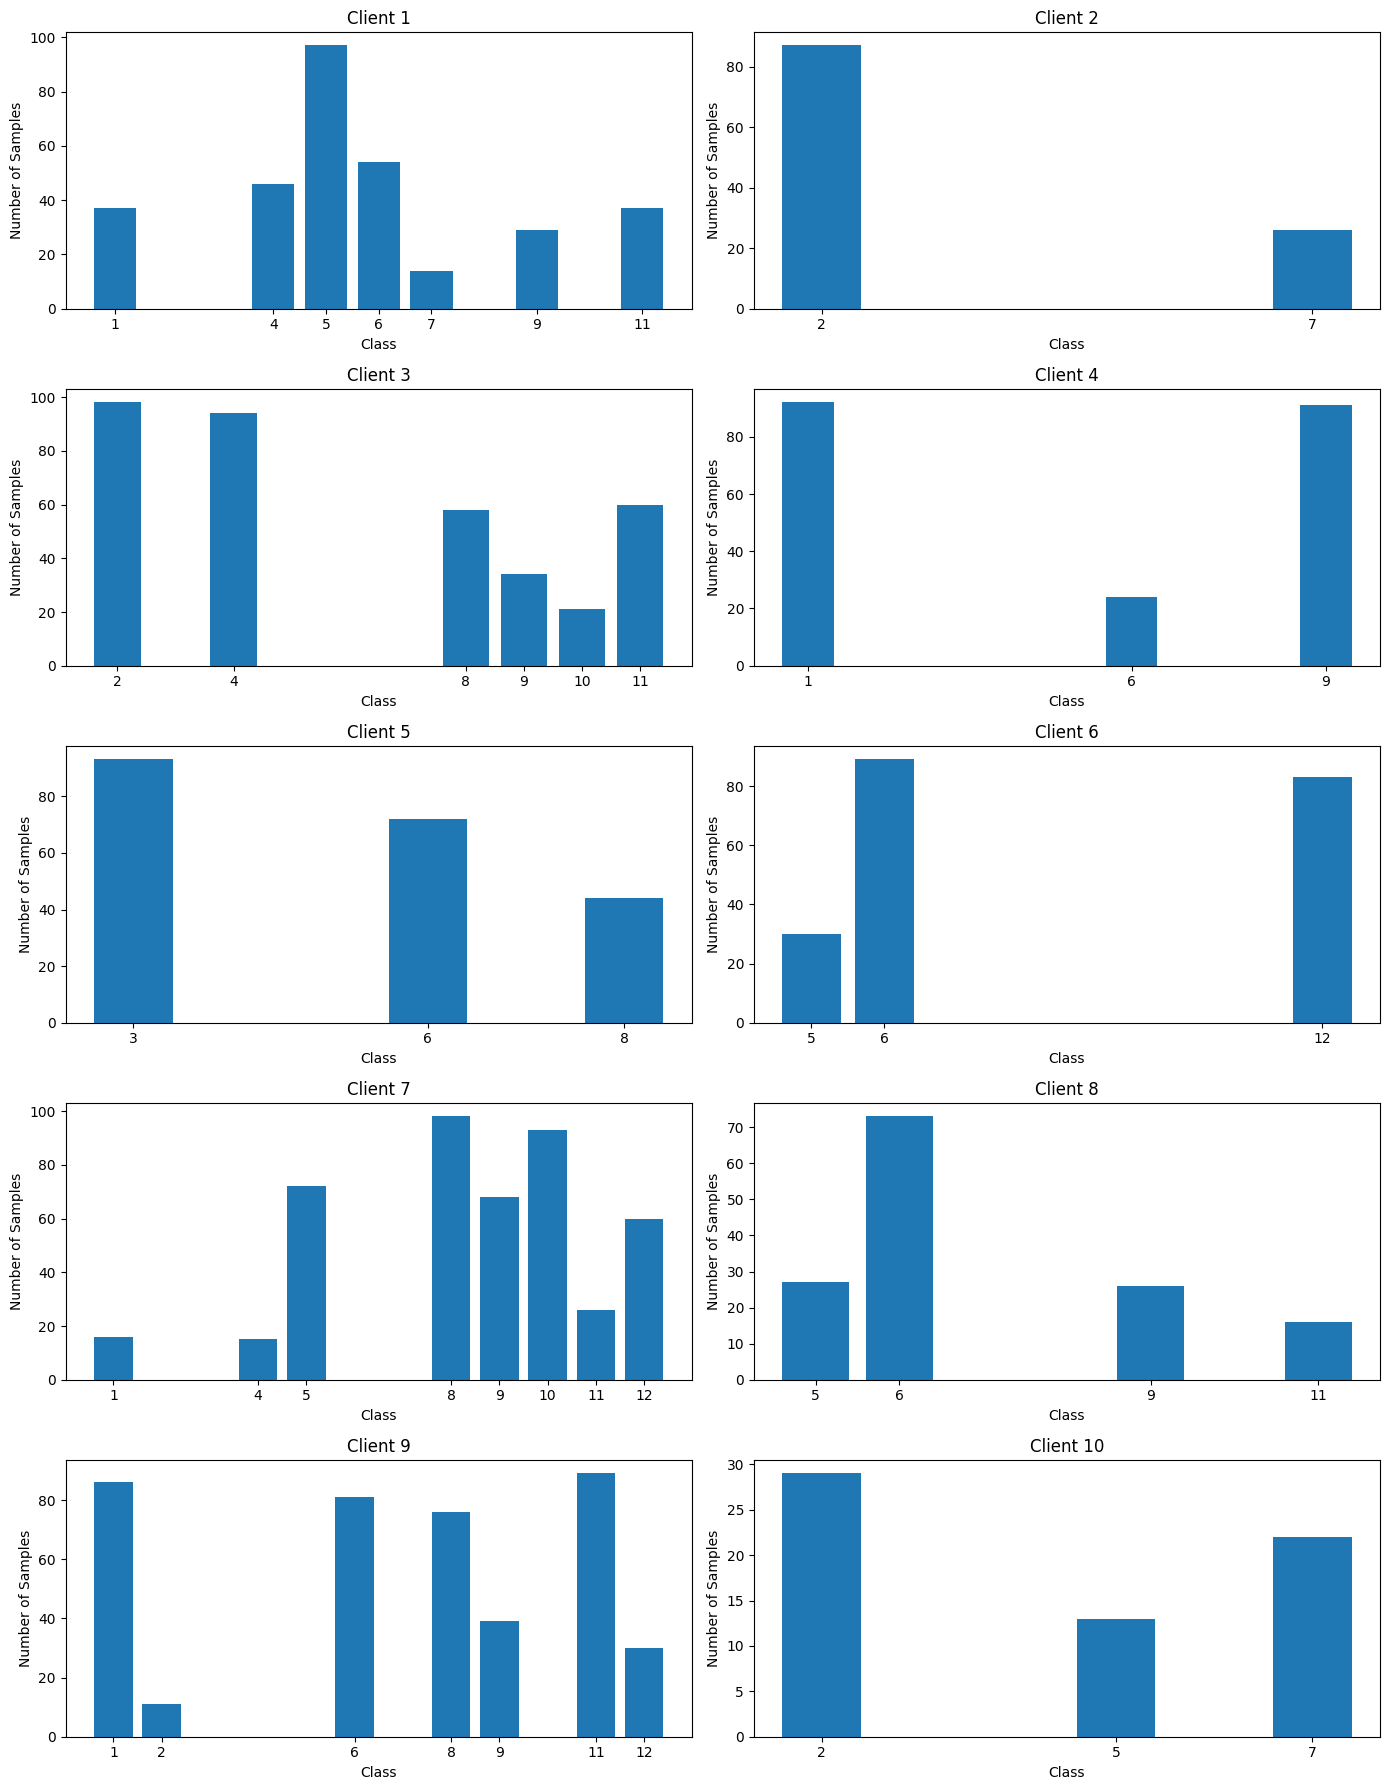

In [5]:
# Plot class distribution per client

fig, axes = plt.subplots(5, 2, figsize=(14, 18))
axes = axes.flatten()

for idx, (client_id, class_counts) in enumerate(client_class_distribution.items()):

    axes[idx].bar(class_counts.index, class_counts.values)
    axes[idx].set_title(f"Client {client_id}")
    axes[idx].set_xlabel("Class")
    axes[idx].set_ylabel("Number of Samples")
    axes[idx].set_xticks(class_counts.index)

plt.tight_layout()
plt.show()

The class distribution analysis shows that clients usually have samples of a few classes only. The dataset is highly non-IID across clients. Each one contains only a subset of the total available classes, and the numbers of the samples per class are as well unbalanced.

For example, Client 2 only contains classes 2 and 7, while Client 5 only contains classes 3,6 and 8. In contrast clients like 7 or 9 have more variety. Additionallly, some classes dominate CLients, like class 5 in Client 1 or class 2 in Client 2.

The heterogeneity is imporatant in Federated Learning, this is because every client trains its local model using only its own local data. This approach allows the raw client data to remain private and never leave the local device, which is one of the main advantages of federated learning compared to centralized machine learning approaches.

As a consequence, local models tend to learn biased representations that specialize in the classes available in each client (in this case). Therefore, the global model must combine knowledge coming from very different local distributions.

The analysis also suggests that some clients may contribute more strongle to the global model than others. This is because the ones with more samples and more class diversity such as Client 7 or 9, are expected to give more information updates during training compared to clients with limited data such as Client 10.

After this, we conclude that federated learning is the  correct method to use instead of assumin a centralized IID scenario. The non-uniform distribution of data makes the optimization process more difficult and may lead to a smaller convergence or differences in the local model performance across clients.

## Test Data Analyisis

In [19]:
# Load test dataset

test_features_file = os.path.join(mypath, "test_features.csv")
test_labels_file = os.path.join(mypath, "test_labels.csv")

X_test = pd.read_csv(test_features_file, header=None)
y_test = pd.read_csv(test_labels_file, header=None).values.flatten()

print("Test features shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

test_class_distribution = pd.Series(y_test).value_counts().sort_index()
print(test_class_distribution)

Test features shape: (500, 270)
Test labels shape: (500,)
1     57
2     51
3     56
4     47
5     50
6     47
7     37
8     17
9     12
10    63
11    52
12    11
Name: count, dtype: int64


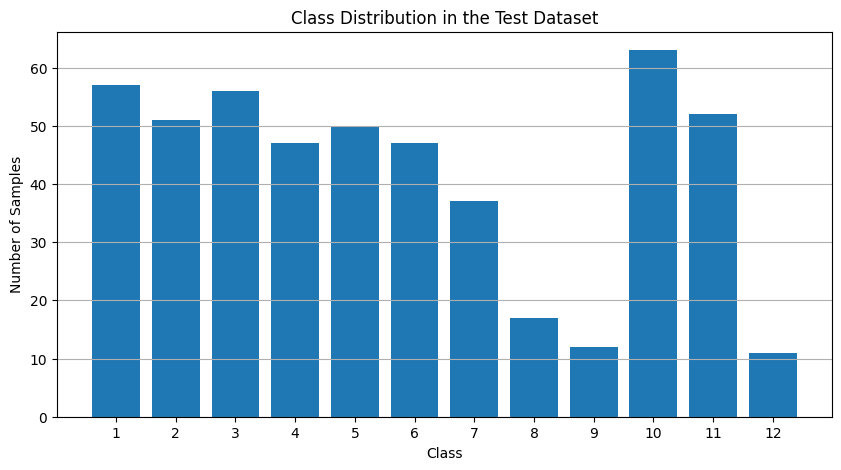

In [7]:
plt.figure(figsize=(10,5))

plt.bar(test_class_distribution.index, test_class_distribution.values)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in the Test Dataset")

plt.xticks(test_class_distribution.index)
plt.grid(axis='y')

plt.show()

The test dataset contains 500 samples with 270 features each. The class distribution is relatively balanced for most classes although some like 8, 9 or 12 contain fewer samples than the rest.

This imbalnce may affect later the performance of the global modle on these minory classes, since, as explained before, will receive less information about them during the evaluation

# 2. Model definition and training

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def create_mlp():

    model = Sequential([
        Input(shape=(270,)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(12, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

global_model = create_mlp()

global_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 128)            │        34,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,724 (170.80 KB)

 Trainable params: 43,724 (170.80 KB)

 Non-trainable params: 0 (0.00 B)

We use a simpli fully connected neural network as the local model for each one of the clients.

The input layer receivves 270 extracted features from the Wi-Fi sensing data. Two hidden layers with ReLU activation used to learn non linear reltionships between features and the activity classes. The output layer contains 12 neurons, which correspond to the 12 activity classes in the dataset. Uses softmax activation function to compute the class probabilities

The reason of selecting this "simple" architecture is because some clients contain limited amounts of data. Using then a lightweight model helps reduce overfitting and also decreases the communication and computational costs during federated learning.

The model summary shows that the network has 43.724 trainable parameters. This confirms that the model is lightweight, which is convenient as we explained before.

In [21]:
# Federated Learning hyperparameters

num_clients = 50
num_rounds = 3
local_epochs = 3
batch_size = 16
participation_rate = 1.0

These hyperparameters define the federated learning process. We use 50 communication rounds, where in each round the clients train locally for 3 epochs before sending their updated model weights to the server.

We use all clients in every round because the dataset only contains 10 clients, so full participation is computationally affordable and avoids adding extra randomness from client selection.

The batch sieze is 16 because is a standard value widely used and provides a balance stable gradient updates and efficient local training. Since the dataset is heteregeneous and some clients have few samples, we keep the number of local epochs moderate to reduce the risk of overfitting.

In [22]:
def train_local_mlp(model, X_client, y_client):

    local_model = create_mlp()

    local_model.set_weights(model.get_weights())

    history = local_model.fit(
        X_client,
        y_client,
        epochs=local_epochs,
        batch_size=batch_size,
        verbose=0
    )

    return local_model.get_weights(), history.history

In [23]:
from sklearn.preprocessing import StandardScaler

all_train_features = pd.concat(
    [client_data[i][0] for i in client_data.keys()],
    axis=0
)

scaler = StandardScaler()
scaler.fit(all_train_features)

prepared_client_data = {}

for client_id, (X_client, y_client) in client_data.items():

    X_client_scaled = scaler.transform(X_client).astype("float32")
    y_client_prepared = y_client.values.flatten().astype("int32") - 1

    prepared_client_data[client_id] = (X_client_scaled, y_client_prepared)

X_test_prepared = scaler.transform(X_test).astype("float32")
y_test_prepared = y_test.astype("int32") - 1

In [24]:
def federated_averaging(local_weights, client_sample_sizes):

    total_samples = np.sum(client_sample_sizes)
    averaged_weights = []

    for layer_weights in zip(*local_weights):

        weighted_layer = np.zeros_like(layer_weights[0])

        for client_weights, client_size in zip(layer_weights, client_sample_sizes):
            weighted_layer += client_weights * (client_size / total_samples)

        averaged_weights.append(weighted_layer)

    return averaged_weights

Federated Averaging is the aggregation algorithm used to combine the knowledge learned independently by all the clients. After local training, the server that has all the model wights, computes the average of them layer by layer in order to create a new global model.

This helps to learn from all client without requiring clients to share their raw data..

In [25]:
def plot_train_test_curves(history, title_prefix=""):

    rounds = list(range(1, len(history['test_loss']) + 1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Accuracy subplot ---
    axes[0].plot(rounds, history['train_acc'], 'b-o', label='Avg Train Accuracy')
    axes[0].plot(rounds, history['test_acc'], 'r-s', label='Test Accuracy')
    axes[0].set_title(f'{title_prefix} Train vs. Test Accuracy')
    axes[0].set_xlabel('Round')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # --- Loss subplot ---
    axes[1].plot(rounds, history['train_loss'], 'b-o', label='Avg Train Loss')
    axes[1].plot(rounds, history['test_loss'], 'r-s', label='Test Loss')
    axes[1].set_title(f'{title_prefix} Train vs. Test Loss')
    axes[1].set_xlabel('Round')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


## MLP

Before training all feature values are converted to float32 format and labels are transformed into integer values between 0 and 11. This is since TensorFlow expects classs indicies starting from zero when using sparse categroical cross entropy.

In each one of the rounds: The current global models is sent to all its clients, every one performs local training using its own dataset. The updated local weights are collected and federated averaging then combines all local models into a new global model. Finally the updated global model is evaluated using the centralized test dataset.

We store the global accuracy and loss after each communication round in order to analyze the learning evolution during training.

The local model training uses the Adam optimizer with a learning rate of 0.0005. This smaller value helps stabilize training because the client datasets are heterogeneous and non-IID. A lower learning rate prevents overly aggressive updates from individual clients as well as improving convergence of the global model.


The following function handles the training process by first receiving the created model and the function to train it locally, to then apply federated learning and print losses and accuracies.

In [26]:
def train_global_model(create_model_function, train_locally, num_rounds):

    # Create a fresh global model
    model = create_model_function()

    # History dict to collect train and test metrics per round
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }

    # Save initial weights
    current_weights = model.get_weights()

    for round_num in range(num_rounds):
        # Free TensorFlow memory from previous round
        tf.keras.backend.clear_session()

        # Recreate global model and restore weights
        model = create_model_function()
        model.set_weights(current_weights)

        print(f"Round {round_num + 1}/{num_rounds}")

        local_weights = []
        client_sample_sizes = []
        round_train_losses = []
        round_train_accs = []

        for client_id in prepared_client_data.keys():
            X_client, y_client = prepared_client_data[client_id]

            local_model_weights, local_history = train_locally(
                model, X_client, y_client
            )

            local_weights.append(local_model_weights)
            n_samples = len(X_client)
            client_sample_sizes.append(n_samples)

            round_train_losses.append(local_history['loss'][-1])
            round_train_accs.append(local_history['accuracy'][-1])

        # Weighted average of train metrics
        total_samples = sum(client_sample_sizes)
        avg_train_loss = sum(
            l * (s / total_samples) for l, s in zip(round_train_losses, client_sample_sizes)
        )
        avg_train_acc = sum(
            a * (s / total_samples) for a, s in zip(round_train_accs, client_sample_sizes)
        )

        # Federated averaging
        current_weights = federated_averaging(local_weights, client_sample_sizes)
        model.set_weights(current_weights)

        # Evaluate on test set
        test_loss, test_accuracy = model.evaluate(
            X_test_prepared, y_test_prepared, verbose=0
        )

        # Store metrics
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_accuracy)

        print(f"  Avg Train Acc: {avg_train_acc:.4f} | Avg Train Loss: {avg_train_loss:.4f}")
        print(f"  Test Acc:      {test_accuracy:.4f} | Test Loss:      {test_loss:.4f}")
        print("-----------------------------")

    return history

In [17]:
# mlp = create_mlp()
history = train_global_model(create_mlp, train_local_mlp, num_rounds=50)

Round 1/50
  Avg Train Acc: 0.3998 | Avg Train Loss: 1.7396
  Test Acc:      0.1220 | Test Loss:      2.5860
-----------------------------
Round 2/50
  Avg Train Acc: 0.4382 | Avg Train Loss: 1.6065
  Test Acc:      0.1580 | Test Loss:      2.5298
-----------------------------
Round 3/50
  Avg Train Acc: 0.4766 | Avg Train Loss: 1.5123
  Test Acc:      0.1900 | Test Loss:      2.5158
-----------------------------
Round 4/50
  Avg Train Acc: 0.5061 | Avg Train Loss: 1.4494
  Test Acc:      0.2300 | Test Loss:      2.5007
-----------------------------
Round 5/50
  Avg Train Acc: 0.5198 | Avg Train Loss: 1.3883
  Test Acc:      0.2400 | Test Loss:      2.4843
-----------------------------
Round 6/50
  Avg Train Acc: 0.5481 | Avg Train Loss: 1.3488
  Test Acc:      0.2580 | Test Loss:      2.4798
-----------------------------
Round 7/50
  Avg Train Acc: 0.5517 | Avg Train Loss: 1.3331
  Test Acc:      0.2620 | Test Loss:      2.4768
-----------------------------
Round 8/50
  Avg Train Acc:

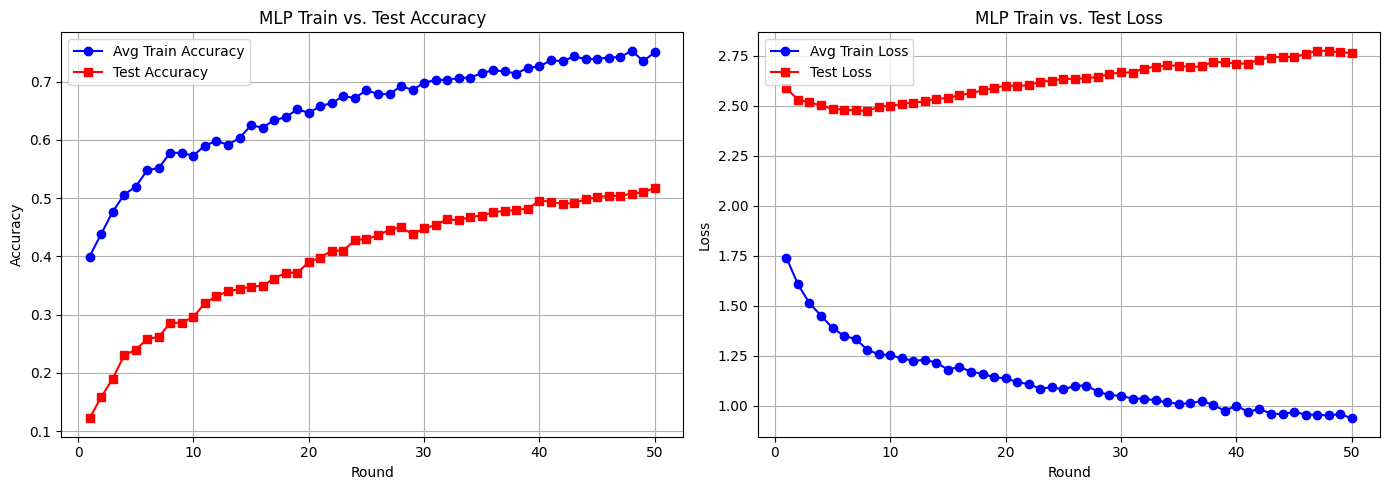

In [18]:
# Plot train vs test curves for the MLP model
plot_train_test_curves(history, title_prefix="MLP")

## CNN

Since the MLP did not achieve an impressive accuracy, we will try a basic CNN. It will be composed by two convolutional layers with max pooling, and a dense classification head. We keep the same optimizer and loss function.

In [27]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Reshape

def create_cnn_model():
    """
    Creates a simple 1D CNN.
    The input (270,) is reshaped to (270, 1) so Conv1D can be applied.
    Architecture:
      - Conv1D(32, kernel_size=5, relu) + MaxPooling1D(2)
      - Conv1D(64, kernel_size=3, relu) + MaxPooling1D(2)
      - Flatten
      - Dense(64, relu) + Dropout(0.3)
      - Dense(12, softmax)
    """
    model = tf.keras.Sequential([
        # Reshape flat input into (270, 1) for Conv1D
        tf.keras.layers.Input(shape=(270,)),
        Reshape((270, 1)),

        # First conv block
        Conv1D(filters=32, kernel_size=5, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),

        # Second conv block
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),

        # Classification head
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(12, activation='softmax'),
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    return model


# Print the CNN model summary
cnn_model_temp = create_cnn_model()
cnn_model_temp.summary()
del cnn_model_temp

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_11 (Reshape)            │ (None, 270, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 270, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_22 (MaxPooling1D) │ (None, 135, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 135, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 67, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 4288)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │       274,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,676 (1.07 MB)

 Trainable params: 281,676 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
def train_local_cnn_model(model, X_client, y_client):
    """
    Trains a local CNN model. Same logic as train_local_model
    but uses create_cnn_model instead of create_model.
    """
    local_model = create_cnn_model()
    local_model.set_weights(model.get_weights())

    history = local_model.fit(
        X_client, y_client,
        epochs=local_epochs,
        batch_size=batch_size,
        verbose=0,
    )

    return local_model.get_weights(), history.history

In [29]:
cnn_history = train_global_model(create_cnn_model, train_local_cnn_model, num_rounds=50)

Round 1/50
  Avg Train Acc: 0.4431 | Avg Train Loss: 1.4209
  Test Acc:      0.1040 | Test Loss:      2.6288
-----------------------------
Round 2/50
  Avg Train Acc: 0.4721 | Avg Train Loss: 1.3390
  Test Acc:      0.1460 | Test Loss:      2.5750
-----------------------------
Round 3/50
  Avg Train Acc: 0.5392 | Avg Train Loss: 1.2242
  Test Acc:      0.1680 | Test Loss:      2.5633
-----------------------------
Round 4/50
  Avg Train Acc: 0.5509 | Avg Train Loss: 1.1649
  Test Acc:      0.1920 | Test Loss:      2.4914
-----------------------------
Round 5/50
  Avg Train Acc: 0.6159 | Avg Train Loss: 1.0286
  Test Acc:      0.2240 | Test Loss:      2.4805
-----------------------------
Round 6/50
  Avg Train Acc: 0.6385 | Avg Train Loss: 0.9633
  Test Acc:      0.2480 | Test Loss:      2.4219
-----------------------------
Round 7/50
  Avg Train Acc: 0.6789 | Avg Train Loss: 0.9046
  Test Acc:      0.2780 | Test Loss:      2.4233
-----------------------------
Round 8/50
  Avg Train Acc:

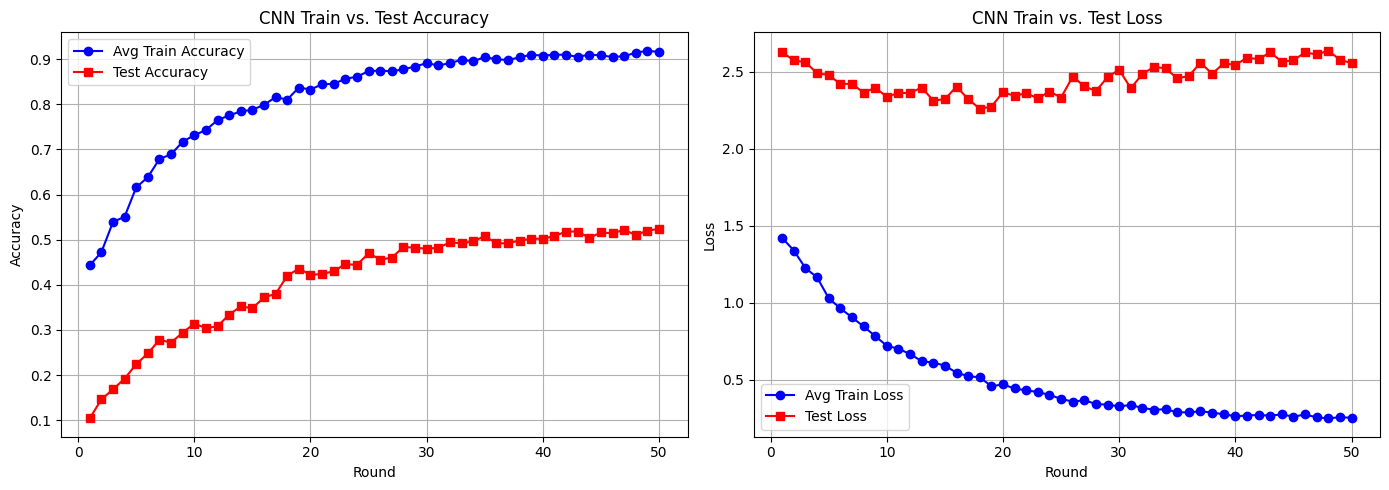

In [30]:
# Plot train vs test curves for the CNN model
plot_train_test_curves(cnn_history, title_prefix="CNN")

# 3. Results

Both the MLP and CNN architectures achieve similar accuracy. The first 10 communication rounds are where they learn faster. The MLP accuracy seems to keep increasing slowly. The CNN converges after the 30th round approximately. We also observe slight fluctuations in accuracy and loss during training. This is expected because the client datasets are heterogeneous and non-IID.

Both models show signs of overfitting the training data. The test accuracy in the MLP is around 24% lower than training. In the CNN, it is around 39% lower. This shows that the test set imposes a challenge to both models, likely because they have poor knowledge on less seen classes.

<Figure size 1000x1000 with 0 Axes>

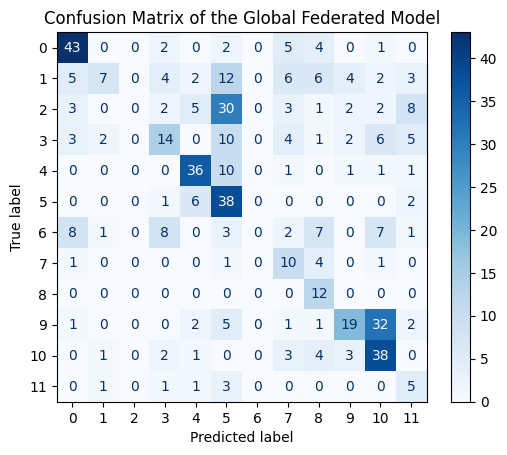

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred_probs = global_model.predict(X_test_prepared, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test_prepared, y_pred)

plt.figure(figsize=(10,10))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')

plt.title("Confusion Matrix of the Global Federated Model")
plt.show()

The confusion matrix shows that the global model correctly classifies several classes, especcially 1, 5, 6 and 11. Some other classes are still confused with others such as 10 being predicted as 11. This could be expected because client datasets are heteregeneous and non-IID.

Overall, despite the models do not achieve great accuracy, they are far better than a random guess (1/12), showing they learned activity patterns without centralizing the clients’ private data.